# Figure 4: affine out-of-plane shear
Panels a and b use fixed regular-prism side lengths, with $x\mapsto x+qz$. Stability refers to this affine family.

In [1]:
# Locate the bundled simulator without requiring an editable installation.
from pathlib import Path
import sys
import tomllib

package_root = None
cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    project_file = candidate / "pyproject.toml"
    if project_file.is_file() and (candidate / "cvm3d" / "__init__.py").is_file():
        project = tomllib.loads(project_file.read_text(encoding="utf-8"))
        if project.get("project", {}).get("name") == "epithelial-cvm3d":
            package_root = candidate
            break

if package_root is not None:
    loaded = sys.modules.get("cvm3d")
    if (
        loaded is not None
        and Path(loaded.__file__).resolve().parent != package_root / "cvm3d"
    ):
        raise RuntimeError(
            "Another cvm3d package is loaded. Restart the kernel and run all cells."
        )
    sys.path.insert(0, str(package_root))

import jax

jax.config.update("jax_enable_x64", True)
import cvm3d


In [2]:
import jax

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D


from cvm3d.z_shear import (
    CellParameters,
    ShearMesh,
    affine_shear_energy_difference,
    affine_shear_magnitude,
    out_of_plane_modulus,
    regular_energy,
    regular_energy_derivative,
)

SQRT3 = np.sqrt(3.0)
V0 = 1.0
KAPPA = 0.1
GAMMA_B = -6.0
MM_TO_INCH = 1.0 / 25.4
PANEL_SIZE = (40 * MM_TO_INCH, 40 * MM_TO_INCH)

ROOT_TOL = 1.0e-8
ROOT_IMAG_TOL = 1.0e-7
ROOT_DEDUP_RTOL = 1.0e-7
CURVATURE_TOL = 1.0e-8
G_TOL = 1.0e-8
FD_STEP = 3.0e-3

MISSING, UNSHEARED, COEXISTENCE, FINITE_SHEAR, SHEAR_BOUNDARY = range(5)
CLASS_NAMES = {
    MISSING: "Missing / invalid",
    UNSHEARED: "Unsheared only, q_0 = 0",
    COEXISTENCE: "Coexistence",
    FINITE_SHEAR: "Finite-shear only, q_0 != 0",
    SHEAR_BOUNDARY: "Affine shear stability boundary",
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 6,
        "axes.labelsize": 5,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 4.5,
        "lines.linewidth": 0.75,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


## Regular-prism branches and affine shear energy
Scalar energies and shear moduli are provided by `cvm3d.z_shear`.

In [3]:
def parameters(param):
    gamma_b, gamma_c, sigma = param
    return CellParameters(
        gamma_b=float(gamma_b),
        gamma_c=float(gamma_c),
        sigma=float(sigma),
        kappa=KAPPA,
        cell_volume=V0,
    )


def _evaluate_scalar_function(function, values, param, *args):
    values = np.asarray(values, dtype=float)
    result = np.array(
        [function(*args, float(value), parameters(param)) for value in values.ravel()]
    ).reshape(values.shape)
    return result.item() if result.ndim == 0 else result


def energy(l, param):
    return _evaluate_scalar_function(regular_energy, l, param)


def denergy_dl(l, param):
    return _evaluate_scalar_function(regular_energy_derivative, l, param)


def d2energy_dl2(l, param):
    gamma_b, gamma_c, _ = param
    l = np.asarray(l, dtype=float)
    return (
        3.0 * SQRT3 * gamma_b
        + (4.0 * SQRT3 / 3.0) * gamma_c * V0 / l**3
        + KAPPA * (64.0 / l**4 + 324.0 * l**2 / V0**2)
    )


def stationary_roots(param):
    """All distinct positive roots of dE/dl=0."""
    gamma_b, gamma_c, sigma = param
    coefficients = [
        324.0 * KAPPA / V0**2,
        0.0,
        9.0 * SQRT3 * gamma_b,
        18.0 * sigma,
        0.0,
        -2.0 * SQRT3 * gamma_c * V0,
        -64.0 * KAPPA,
    ]
    roots = []
    for candidate in sorted(np.roots(coefficients), key=lambda value: value.real):
        if candidate.real <= 0.0:
            continue
        if abs(candidate.imag) > ROOT_IMAG_TOL * max(1.0, abs(candidate.real)):
            continue
        root = float(candidate.real)
        for _ in range(6):
            residual = denergy_dl(root, param)
            curvature = float(d2energy_dl2(root, param))
            if abs(residual) < 0.1 * ROOT_TOL or abs(curvature) < 1.0e-14:
                break
            updated = root - residual / curvature
            if updated <= 0.0 or not np.isfinite(updated):
                break
            root = float(updated)
        if abs(denergy_dl(root, param)) > ROOT_TOL:
            continue
        if not roots or not np.isclose(
            root, roots[-1], rtol=ROOT_DEDUP_RTOL, atol=1.0e-10
        ):
            roots.append(root)
    return np.asarray(roots)


def stable_branches(param):
    roots = stationary_roots(param)
    curvatures = np.asarray(d2energy_dl2(roots, param))
    stable = curvatures > CURVATURE_TOL
    return roots[stable], curvatures[stable]


def g_perp(l0, param):
    return _evaluate_scalar_function(out_of_plane_modulus, l0, param)


def delta_energy(q, l0, param):
    return _evaluate_scalar_function(
        affine_shear_energy_difference, q, param, float(l0)
    )


def affine_energy(q, l0, param):
    return energy(l0, param) + delta_energy(q, l0, param)


def finite_q0(l0, param):
    return affine_shear_magnitude(float(l0), parameters(param))


def denergy_dq(q, l0, param):
    _, gamma_c, _ = param
    return gamma_c * V0 * q / (
        SQRT3 * l0 * np.sqrt(1.0 + 0.75 * q**2)
    ) + 32.0 * KAPPA * q / (3.0 * l0**2)


def classify_moduli(moduli):
    moduli = np.asarray(moduli)
    if moduli.size == 0:
        return MISSING
    positive = moduli > G_TOL
    negative = moduli < -G_TOL
    if np.any(~(positive | negative)):
        return SHEAR_BOUNDARY
    if np.all(positive):
        return UNSHEARED
    if np.all(negative):
        return FINITE_SHEAR
    return COEXISTENCE


## Stability map and representative landscapes
Coordinates and display ranges are specified below. I has one unsheared branch, II has coexisting branches, and III has a finite-shear branch.


In [4]:
# Edit the coordinates and q limits independently for each representative.
# gamma_b, kappa, and V0 are shared constants defined above.
REPRESENTATIVE_POINTS = {
    "I": dict(gamma_c=-8.0, sigma=3.0, q_range=(-3.0, 3.0)),
    "II": dict(gamma_c=-5.0, sigma=2.5, q_range=(-7.0, 7.0)),
    "III": dict(gamma_c=-3.0, sigma=1.0, q_range=(-5.0, 5.0)),
}
Q_SAMPLES = 201

POINT_CLASSES = {
    "I": (UNSHEARED, 1),
    "II": (COEXISTENCE, 2),
    "III": (FINITE_SHEAR, 1),
}


In [5]:
gamma_c_values = np.linspace(-10.0, 0.0, 201)
sigma_values = np.linspace(0.0, 4.0, 201)
map_shape = (len(sigma_values), len(gamma_c_values))

stability_map = np.zeros(map_shape, dtype=int)
number_of_minima = np.zeros(map_shape, dtype=int)
for i, sigma in enumerate(sigma_values):
    for j, gamma_c in enumerate(gamma_c_values):
        param = (GAMMA_B, gamma_c, sigma)
        minima, _ = stable_branches(param)
        moduli = np.asarray(g_perp(minima, param))
        number_of_minima[i, j] = len(minima)
        stability_map[i, j] = classify_moduli(moduli)

missing_count = int(np.count_nonzero(stability_map == MISSING))
boundary_count = int(np.count_nonzero(stability_map == SHEAR_BOUNDARY))
print(f"grid points: {stability_map.size:,}")
print(f"missing / invalid: {missing_count}")
print(f"|G_perp| <= {G_TOL:.0e}: {boundary_count}")
for code in (UNSHEARED, COEXISTENCE, FINITE_SHEAR):
    count = np.count_nonzero(stability_map == code)
    print(f"{CLASS_NAMES[code]}: {count:,}")


grid points: 40,401
missing / invalid: 0
|G_perp| <= 1e-08: 0
Unsheared only, q_0 = 0: 16,544
Coexistence: 7,284
Finite-shear only, q_0 != 0: 16,573


In [6]:
q_values_by_point = {}
representative_data = {}
validation_rows = []
modulus_errors = []


def second_derivative_fd(function, step=FD_STEP):
    return (
        -function(2 * step)
        + 16 * function(step)
        - 30 * function(0.0)
        + 16 * function(-step)
        - function(-2 * step)
    ) / (12 * step**2)


for label, point in REPRESENTATIVE_POINTS.items():
    param = (GAMMA_B, point["gamma_c"], point["sigma"])
    q_min, q_max = point["q_range"]
    if not (np.isfinite([q_min, q_max]).all() and q_min < q_max):
        raise ValueError(
            f"Point {label}: q_range must contain finite bounds with min < max"
        )
    q_values = np.linspace(q_min, q_max, Q_SAMPLES)
    q_values_by_point[label] = q_values
    if not (
        gamma_c_values[0] <= point["gamma_c"] <= gamma_c_values[-1]
        and sigma_values[0] <= point["sigma"] <= sigma_values[-1]
    ):
        raise ValueError(
            f"Point {label}: coordinates must lie inside the stability map"
        )

    minima, curvatures = stable_branches(param)
    moduli = np.asarray(g_perp(minima, param))
    expected_class, expected_branches = POINT_CLASSES[label]
    if len(minima) != expected_branches or classify_moduli(moduli) != expected_class:
        raise ValueError(
            f"Point {label}: choose coordinates in {CLASS_NAMES[expected_class]} "
            f"with {expected_branches} stable branch(es); got "
            f"{CLASS_NAMES[classify_moduli(moduli)]} with {len(minima)} branch(es)"
        )
    assert np.min(np.abs(moduli)) > 100 * G_TOL

    branches = []
    for branch_index, (l0, curvature, modulus) in enumerate(
        zip(minima, curvatures, moduli), start=1
    ):
        curve = np.asarray(delta_energy(q_values, l0, param))
        q0 = float(finite_q0(l0, param))
        root_error = abs(denergy_dl(l0, param))
        fd_modulus = second_derivative_fd(lambda q: affine_energy(q, l0, param))
        absolute_error = abs(fd_modulus - modulus)
        relative_error = absolute_error / abs(modulus)

        assert root_error <= ROOT_TOL
        assert curvature > CURVATURE_TOL
        assert np.isclose(fd_modulus, modulus, rtol=1.0e-7, atol=1.0e-7)
        assert abs(delta_energy(0.0, l0, param)) < 1.0e-14

        if modulus > G_TOL:
            branch_class = "Unsheared"
        else:
            assert q0 > 0.0
            assert abs(denergy_dq(q0, l0, param)) < 1.0e-9
            assert (
                abs(delta_energy(q0, l0, param) - delta_energy(-q0, l0, param))
                < 1.0e-12
            )
            branch_class = "Finite shear"

        branches.append(
            {
                "l0": float(l0),
                "curvature": float(curvature),
                "modulus": float(modulus),
                "q0": q0,
                "curve": curve,
                "minimum_energy": float(delta_energy(q0, l0, param)),
            }
        )
        validation_rows.append(
            (
                label,
                point["gamma_c"],
                point["sigma"],
                branch_index,
                l0,
                curvature,
                modulus,
                root_error,
                absolute_error,
                relative_error,
                branch_class,
                CLASS_NAMES[expected_class],
            )
        )
        modulus_errors.append((absolute_error, relative_error))
    representative_data[label] = branches

# Point II must contain both signs, and panels a and b must use the same classes.
assert any(branch["modulus"] > G_TOL for branch in representative_data["II"])
assert any(branch["modulus"] < -G_TOL for branch in representative_data["II"])
(ii_finite_branch,) = [
    branch for branch in representative_data["II"] if branch["modulus"] < -G_TOL
]
ii_inset_values = np.r_[ii_finite_branch["curve"], ii_finite_branch["minimum_energy"]]
ii_inset_y_range = (
    min(-0.1, 1.2 * ii_inset_values.min()),
    max(0.1, 1.2 * ii_inset_values.max()),
)

header = (
    f"{'point':<5} {'gamma_c':>8} {'sigma':>7} {'branch':>7} {'l_0':>11} "
    f"{'d2E/dl2':>12} {'G_perp':>12} {'|dE/dl|':>11} {'abs. err.':>11} "
    f"{'rel. err.':>11}  {'branch class':<12} point class"
)
print(header)
print("-" * len(header))
for row in validation_rows:
    (
        label,
        gamma_c,
        sigma,
        branch,
        l0,
        curvature,
        modulus,
        residual,
        absolute_error,
        relative_error,
        branch_class,
        point_class,
    ) = row
    print(
        f"{label:<5} {gamma_c:8.2f} {sigma:7.2f} {branch:7d} {l0:11.8f} "
        f"{curvature:12.6f} {modulus:12.6f} {residual:11.2e} "
        f"{absolute_error:11.2e} {relative_error:11.2e}  "
        f"{branch_class:<12} {point_class}"
    )

maximum_modulus_absolute_error = max(error[0] for error in modulus_errors)
maximum_modulus_relative_error = max(error[1] for error in modulus_errors)
print(f"maximum modulus absolute error: {maximum_modulus_absolute_error:.3e}")
print(f"maximum modulus relative error: {maximum_modulus_relative_error:.3e}")


point  gamma_c   sigma  branch         l_0      d2E/dl2       G_perp     |dE/dl|   abs. err.   rel. err.  branch class point class
----------------------------------------------------------------------------------------------------------------------------------
I        -8.00    3.00       1  0.21821871  1014.798620     1.233900    2.30e-14    4.34e-10    3.52e-10  Unsheared    Unsheared only, q_0 = 0
II       -5.00    2.50       1  0.33697951   167.069021     0.826828    7.61e-15    2.18e-10    2.64e-10  Unsheared    Coexistence
II       -5.00    2.50       2  1.26628192    17.577769    -1.614483    3.55e-14    9.69e-11    6.00e-11  Finite shear Coexistence
III      -3.00    1.00       1  1.57619070    48.584552    -0.669534    1.42e-14    1.10e-10    1.64e-10  Finite shear Finite-shear only, q_0 != 0
maximum modulus absolute error: 4.343e-10
maximum modulus relative error: 3.520e-10


## Figure 4a: affine shear stability map

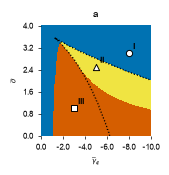

In [7]:
colors = ["#bdbdbd", "#0072B2", "#F0E442", "#D55E00", "#404040"]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 5.5), cmap.N)
x_centers = np.arange(len(gamma_c_values)) + 0.5
y_centers = np.arange(len(sigma_values)) + 0.5

fig, ax = plt.subplots(figsize=(44 * MM_TO_INCH, 44 * MM_TO_INCH))
ax.pcolormesh(
    np.arange(len(gamma_c_values) + 1),
    np.arange(len(sigma_values) + 1),
    stability_map,
    cmap=cmap,
    norm=norm,
    shading="flat",
)

# Dotted line: the in-plane mono-/bistable boundary.
ax.contour(
    x_centers,
    y_centers,
    number_of_minima,
    levels=[1.5],
    colors="black",
    linestyles=":",
    linewidths=0.9,
)

markers = {"I": "o", "II": "^", "III": "s"}
for label, point in REPRESENTATIVE_POINTS.items():
    x = np.interp(point["gamma_c"], gamma_c_values, x_centers)
    y = np.interp(point["sigma"], sigma_values, y_centers)
    ax.scatter(
        x,
        y,
        marker=markers[label],
        s=20,
        facecolor="white",
        edgecolor="black",
        linewidth=0.7,
        zorder=5,
        clip_on=False,
    )
    ax.annotate(
        label,
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=6,
        fontweight="bold",
    )

ix = np.linspace(0, len(gamma_c_values) - 1, 6).round().astype(int)
iy = np.linspace(0, len(sigma_values) - 1, 6).round().astype(int)
ax.set_xticks(ix + 0.5)
ax.set_yticks(iy + 0.5)
ax.set_xticklabels([f"{gamma_c_values[i]:.1f}" for i in ix])
ax.set_yticklabels([f"{sigma_values[i]:.1f}" for i in iy])
ax.set_xlim(len(gamma_c_values), 0)
ax.set_ylim(0, len(sigma_values))
ax.set_aspect("equal")
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set(xlabel=r"$\widetilde\gamma_c$", ylabel=r"$\widetilde\sigma$", title="a")
fig.tight_layout()
plt.show()


## Panel b: representative energy landscapes

In [8]:
def plot_landscape(label):
    point = REPRESENTATIVE_POINTS[label]
    q_values = q_values_by_point[label]
    fig, ax = plt.subplots(figsize=PANEL_SIZE)

    ax.axhline(0.0, color="0.75", lw=0.5)
    for branch in representative_data[label]:
        positive = branch["modulus"] > 0.0
        color = "tab:blue" if positive else "tab:orange"
        linestyle = "-" if positive else "--"
        sign = ">" if positive else "<"
        ax.plot(
            q_values,
            branch["curve"],
            color=color,
            ls=linestyle,
            label=rf"$l_0={branch['l0']:.3f}$, $\tilde G_\perp {sign}0$",
        )
        if branch["q0"] > 0.0:
            ax.plot(
                [-branch["q0"], branch["q0"]],
                [branch["minimum_energy"], branch["minimum_energy"]],
                "o",
                ms=2.5,
                mfc="white",
                mec=color,
                mew=0.7,
            )
    ax.set_xlim(q_values[0], q_values[-1])

    if label == "II":

        q_star = ii_finite_branch["q0"]
        minimum = ii_finite_branch["minimum_energy"]
        inset = ax.inset_axes([0.30, 0.52, 0.40, 0.34])
        inset.set_facecolor("white")
        inset.axhline(0.0, color="0.75", lw=0.4, zorder=0)
        inset.plot(
            q_values,
            ii_finite_branch["curve"],
            color="tab:orange",
            ls="--",
            lw=0.7,
            zorder=2,
        )
        inset.plot(
            [-q_star, q_star],
            [minimum, minimum],
            "o",
            ms=2.0,
            mfc="white",
            mec="tab:orange",
            mew=0.55,
            zorder=3,
        )
        inset.set_xlim(q_values[0], q_values[-1])
        inset.set_ylim(*ii_inset_y_range)
        inset.xaxis.set_major_locator(plt.MaxNLocator(3))
        inset.yaxis.set_major_locator(plt.MaxNLocator(3))
        inset.tick_params(labelsize=6, length=1.5, width=0.4, pad=1)
    ax.set(xlabel=r"$q$", ylabel=r"$\Delta\widetilde E_{\mathrm{cell}}$", title=label)
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig, ax


### I

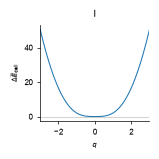

In [9]:
fig, ax = plot_landscape("I")
plt.show()


### II

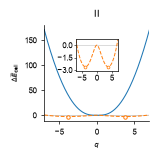

In [10]:
fig, ax = plot_landscape("II")
plt.show()


### III

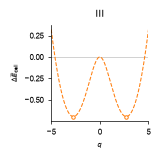

In [11]:
fig, ax = plot_landscape("III")
plt.show()
